
# SVM&앙상블 (Bagging & AdaBoost): breast cancer분석

>사용할 데이터: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data



**목적: 세포핵의 여러 특징을 통해 악성/ 양성 유방암 종양 구분**

양성(B): 정상 조직에 가까운 비암성 종양.

악성(M): 암성 종양.


SVM과  앙상블 모델(Bagging, AdaBoost) 중
어느 쪽이 악성/양성 유방암 종양을 더 잘 구분하는가


> **참고:** SVM은 선형 커널(linear kernel)만 사용할거임



1. 데이터 업로드
2. 데이터 정제
3. 데이터 분석 (EDA)
4. 공통 전처리 (학습/테스트 분할, 스케일링)
5. baseline — decision tree (Cost complexity pruning 이용)
6. 모델 A — SVM
7. 모델 B — Bagging
8. 모델 C — AdaBoost
9. 세 모델  비교
10. Decision Boundary 시각화
11. 오류 분석
12. 결론


## 1. 데이터 업로드

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

df = pd.read_csv("data.csv")
df.shape

(569, 33)

데이터 열 확인

In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 2. 데이터 정제

CSV 파일에서 모델 학습에는 쓸모없는 `id` 열과  `Unnamed` 열을 제거함.


 결측값 유무와 클래스 비율(양성/악성)을 확인해야함

In [ ]:
#  분석에 쓸모없는 열 제거
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.drop(columns=['id'])

print(df.isnull().sum().sum(), "개의 결측값")
df['diagnosis'].value_counts()

0 개의 결측값


,count
diagnosis,
B,357
M,212


## 3.  데이터 분석 (EDA)

총 569개 샘플과, 세포핵의 특징을 나타내는 **10개의 기본 특성**

(반지름, 질감, 둘레, 면적, 매끄러움, 조밀도,
오목함, 오목한 점 개수, 대칭성, 프랙탈 차원)으로 이루어져 있다.


---


각 특성은 `_mean`(평균),
`_se`(표준오차), `_worst`(최댓값) 세 가지로 요약되어 총 30개 열로 구성됨.

target변수는 `diagnosis`,

 **B**는 양성(정상), **M**악성(암세포)

  M(악성)을 1 / B(양성)을 0으로 인코딩

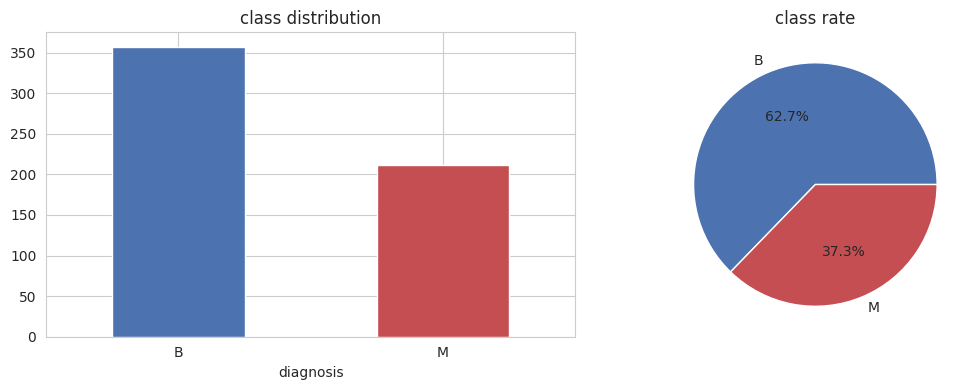

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df['diagnosis'].value_counts().plot(kind='bar', ax=ax[0], color=['#4C72B0', '#C44E52'])
ax[0].set_title('class distribution')
ax[0].set_xticklabels(['B', 'M'], rotation=0)

df['diagnosis'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[1],
                                     colors=['#4C72B0', '#C44E52'], ylabel='')
ax[1].set_title('class rate')
plt.tight_layout()
plt.show()

정상 세포 62.7%
  암 세포 37.3%

비율로 존재하고 있음

## 4. 공통 전처리

 모든 모델은 동일한 training /test set과 scale을 사용
 > (성능 차이가 전처리 방식이 아니라 알고리즘 자체의 차이에서 나오도록 하기)

 feature scaling은 거리 기반 모델인 SVM에는 영향이 있지만 트리 기반 앙상블에는 영향이
적다. 다만 일관성을 위해 모든 모델에 동일하게 적용해야함

In [ ]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis'].map({'B': 0, 'M': 1})  # 1 = 악성 (양성 클래스로 취급)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


>데이터를 `training` : `test` =  8:2 비율로 나눴음

 마지막에 각 모델마다 성능을 비교하기 위해 accuracy, precision,recall,f1-score,roc curve, 학습시간 저장할 저장소(?)를 만들기

In [ ]:
# 최종 비교표/그래프를 위한 결과 저장
results = {}

def evaluate(name, model, X_tr, X_te, fit_time=None):
    t0 = time.time()
    if fit_time is None:
        model.fit(X_tr, y_train)
        fit_time = time.time() - t0
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_te)

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'fit_time': fit_time,
    }
    print(f"[{name}]  정확도={results[name]['accuracy']:.4f}  f1={results[name]['f1']:.4f}  "
          f"roc_auc={results[name]['roc_auc']:.4f}  학습시간={fit_time:.4f}초")
    return model



## 5. 베이스라인 — Decision Tree (Cost complexity pruning이용)

트리 깊이를 처음부터 제한하는 대신, 가지치기를 하지 않고 끝까지 완전히 키운 트리를 먼저 만든다

이 트리는 overfitting 상태일거임 여기에 **cost-complexity pruning** 를 적용해, 쓸모없는 가지를 순서대로 잘라내는 후보 트리들을 얻는다. 각 후보는 가지치기 강도를 나타내는 `ccp_alpha`(cost complexity pruning 에 쓰이는 alpha)
값으로 표현되며, F1 점수가 가장 좋은 `ccp_alpha`를 선택해 최종 베이스라인 트리를
결정


In [ ]:
# 1) 가지치기 없이 완전히 키운 트리에서 가능한 ccp_alpha 후보들을 뽑는다
full_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
path = full_tree.cost_complexity_pruning_path(X_train_s, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # 마지막 값은 root 노드 하나만 남기는 극단적인 경우라 제외

print(f"탐색할 ccp_alpha 후보 개수: {len(ccp_alphas)}")

# 2) 교차검증으로 F1이 가장 좋은 ccp_alpha 탐색 (= weakest-link pruning 강도 결정)
tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {'ccp_alpha': ccp_alphas}, cv=5, scoring='f1', n_jobs=-1
)
tree_grid.fit(X_train_s, y_train)

print("최적 ccp_alpha:", round(tree_grid.best_params_['ccp_alpha'], 5))


baseline_tree = tree_grid.best_estimator_
print(f"가지치기 후 트리 깊이: {baseline_tree.get_depth()}, 리프 개수: {baseline_tree.get_n_leaves()}")
##test set 결과 베이스 라인 저장
evaluate("decision tree", baseline_tree, X_train_s, X_test_s, fit_time=None)

탐색할 ccp_alpha 후보 개수: 17
최적 ccp_alpha: 0.0044
가지치기 후 트리 깊이: 5, 리프 개수: 11
[decision tree]  정확도=0.9386  f1=0.9114  roc_auc=0.9239  학습시간=0.0147초


DecisionTreeClassifier(ccp_alpha=np.float64(0.004395604395604396),
                       random_state=42)

## 6. 모델 A — SVM



In [ ]:
param_grid_svm = {'C': [0.01, 0.1, 1, 10, 100]}

svm_grid = GridSearchCV(SVC(kernel='linear', probability=True, random_state=RANDOM_STATE),
                         param_grid_svm, cv=5, scoring='f1', n_jobs=-1)
svm_grid.fit(X_train_s, y_train)
##cv f1: k-fold cross validation, k=5
##5조각으로 training data나누고 4조각으로 학습, 나머지 1조각으로 f1을 계산-> 5번 반복-> 5번의 f1을 평균냄
print("최적 SVM 파라미터:", svm_grid.best_params_)
print("최적 CV F1:", round(svm_grid.best_score_, 4))
## 최적 cv f1이 나오게 하는 파라미터를 골랐다는 뜻
best_svm = svm_grid.best_estimator_

## test 셋
evaluate("SVM", best_svm, X_train_s, X_test_s, fit_time=None)

최적 SVM 파라미터: {'C': 10}
최적 CV F1: 0.9577
[SVM]  정확도=0.9737  f1=0.9630  roc_auc=0.9868  학습시간=0.0306초


SVC(C=10, kernel='linear', probability=True, random_state=42)

## 7. 모델 B — Bagging

BaggingClassifier이므로 다수결 투표로 클래스를 예측함

In [ ]:
param_grid_bag = {
    'n_estimators': [10, 50, 100, 200],
    'max_samples': [0.5, 0.8, 1.0],
}
bag_base = DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)  # 의도적으로 가지치기하지 않음
bag_grid = GridSearchCV(
    BaggingClassifier(estimator=bag_base, random_state=RANDOM_STATE),
    param_grid_bag, cv=5, scoring='f1', n_jobs=-1
)
bag_grid.fit(X_train_s, y_train)

print("최적 Bagging 파라미터:", bag_grid.best_params_)
print("최적 CV F1:", round(bag_grid.best_score_, 4))

best_bag = bag_grid.best_estimator_
evaluate("Bagging", best_bag, X_train_s, X_test_s)

최적 Bagging 파라미터: {'max_samples': 1.0, 'n_estimators': 200}
최적 CV F1: 0.9487
[Bagging]  정확도=0.9737  f1=0.9630  roc_auc=0.9906  학습시간=2.4394초


BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=200, random_state=42)

## 8. 모델 C — AdaBoost

AdaBoost는 약한 모델들을 순서대로 학습시키면서, 이전 단계에서 잘못 분류된 샘플에 더 큰
가중치를 부여해 다음 모델이 그 실수에 집중하도록 만든다.

In [ ]:
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
}
ada_base = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
ada_grid = GridSearchCV(
    AdaBoostClassifier(estimator=ada_base, random_state=RANDOM_STATE),
    param_grid_ada, cv=5, scoring='f1', n_jobs=-1
)
ada_grid.fit(X_train_s, y_train)

print("최적 AdaBoost 파라미터:", ada_grid.best_params_)
print("최적 CV F1:", round(ada_grid.best_score_, 4))

best_ada = ada_grid.best_estimator_
evaluate("AdaBoost", best_ada, X_train_s, X_test_s)

최적 AdaBoost 파라미터: {'learning_rate': 1.0, 'n_estimators': 200}
최적 CV F1: 0.9524
[AdaBoost]  정확도=0.9737  f1=0.9630  roc_auc=0.9871  학습시간=1.1868초


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   n_estimators=200, random_state=42)

## 9. 세 모델 비교

In [ ]:
summary = pd.DataFrame({k: {m: v[m] for m in ['accuracy','precision','recall','f1','roc_auc','fit_time']}
                         for k, v in results.items()}).T.sort_values('f1', ascending=False)
summary.style.background_gradient(cmap='Greens', subset=['accuracy','precision','recall','f1','roc_auc'])

,accuracy,precision,recall,f1,roc_auc,fit_time
SVM,0.973684,1.000000,0.928571,0.962963,0.986772,0.030624
Bagging,0.973684,1.000000,0.928571,0.962963,0.990575,2.439425
AdaBoost,0.973684,1.000000,0.928571,0.962963,0.987103,1.186793
decision tree,0.938596,0.972973,0.857143,0.911392,0.923942,0.014699


/tmp/ipykernel_448/627447903.py:6: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_448/627447903.py:6: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_448/627447903.py:6: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_448/627447903.py:6: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_448/627447903.py:6: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_448/627447903.py:6: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_448/627447903.py:6: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipyk

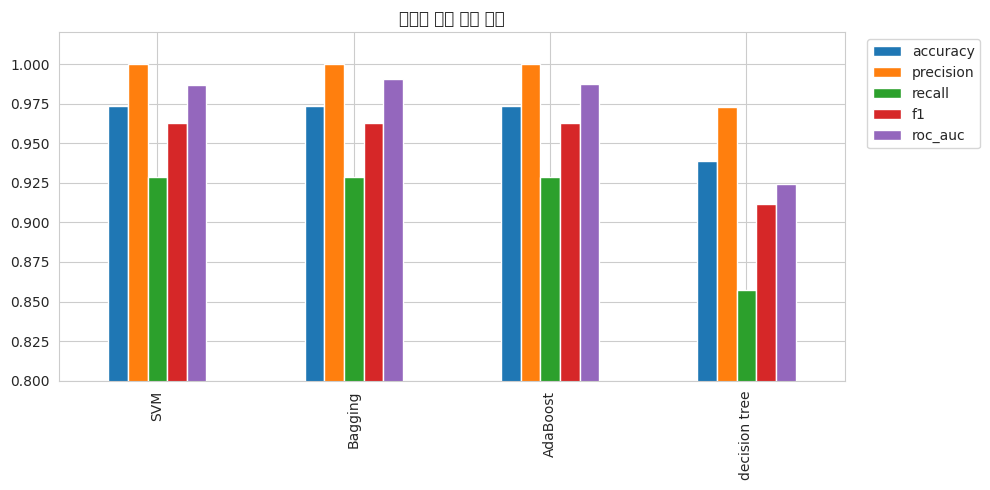

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
summary[['accuracy','precision','recall','f1','roc_auc']].plot(kind='bar', ax=ax)
ax.set_title('모델별 성능 지표 비교')
ax.set_ylim(0.8, 1.02)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

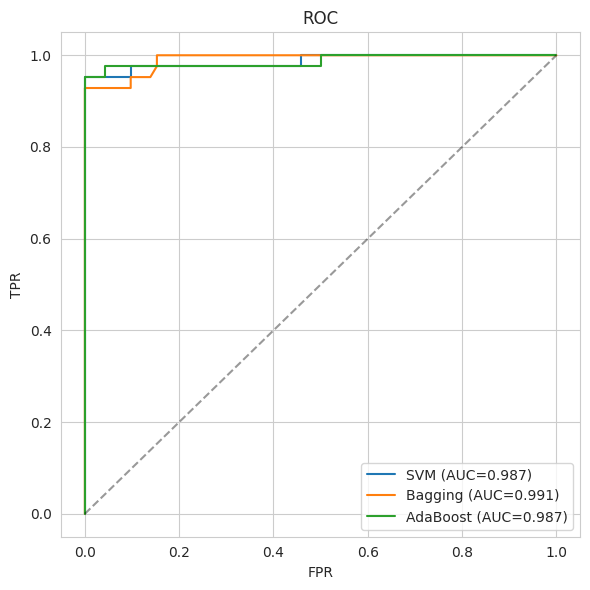

In [ ]:
# 세 주요 모델의 ROC 곡선
plt.figure(figsize=(6, 6))
for name in ["SVM", "Bagging", "AdaBoost"]:
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]['roc_auc']:.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC')
plt.legend()
plt.tight_layout()
plt.show()

## 10. 결정 경계


설명된 분산 비율 (주성분 2개): 0.631


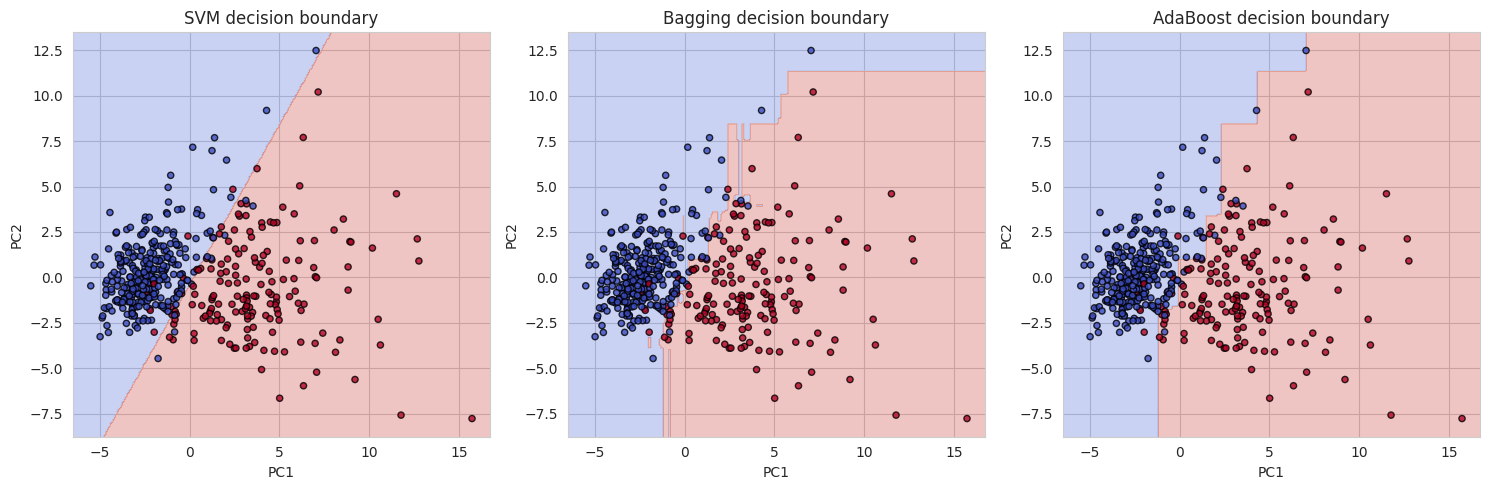

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_s)
X_test_2d = pca.transform(X_test_s)
print("설명된 분산 비율 (주성분 2개):", pca.explained_variance_ratio_.sum().round(3))

viz_models = {
    "SVM": SVC(kernel='linear', C=10, random_state=RANDOM_STATE),
    "Bagging": BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                                  n_estimators=100, random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
                                    n_estimators=100, random_state=RANDOM_STATE),
}

xx, yy = np.meshgrid(
    np.linspace(X_train_2d[:,0].min()-1, X_train_2d[:,0].max()+1, 300),
    np.linspace(X_train_2d[:,1].min()-1, X_train_2d[:,1].max()+1, 300)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, m) in zip(axes, viz_models.items()):
    m.fit(X_train_2d, y_train)
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_train_2d[:,0], X_train_2d[:,1], c=y_train, cmap='coolwarm',
               edgecolor='k', s=20, alpha=0.8)
    ax.set_title(f"{name} decision boundary")
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

## 11. 오류 분석

SVM, bagging,Adaboosting 의 accuracy가 0.973684, f1-score가 0.962963로 모두 동일하게 나왔다.
모든 모델이 틀리는게 동일한지 알아보기

>세모델이 정확하게 같은 샘플에서만 틀렸다면 데이터의 한계라고 생각


>모델마다 틀리는 지점이 다르다면 각 모델이 데이터에서 서로 다른 패턴을 포착하고 있다는 뜻이 됨

In [ ]:
errors = pd.DataFrame({
    name: (results[name]['y_pred'] != y_test.values).astype(int)
    for name in ["SVM", "Bagging", "AdaBoost"]
}, index=y_test.index)

# 각 샘플마다 '몇 개의 모델이' 틀렸는지 세서, 그 값별로 샘플 수를 집계
# 0 = 셋 다 맞춤 / 1 = 딱 한 모델만 틀림(모델마다 실수 지점이 다름) / 3 = 셋 다 틀림(공통으로 어려운 샘플)
overlap = errors.sum(axis=1).value_counts().sort_index()
overlap.index.name = "틀린 모델 개수"
overlap.name = "샘플 수"
print(overlap)

틀린 모델 개수
0    109
1      2
2      2
3      1
Name: 샘플 수, dtype: int64


3개의 모델이 모두 틀리는 경우는 1번 뿐임-> 모델마다 틀리는 지점이 다르다

## 12. 결론

| 모델 | 정확도 | F1 | ROC-AUC |
|---|---|---|---|
| Decision Tree (baseline) | 0.939 | 0.911 | 0.924 |
| SVM | 0.974 | 0.963 | 0.987 |
| Bagging | 0.974 | 0.963 | **0.991** |
| AdaBoost | 0.974 | 0.963 | 0.987 |

- SVM·Bagging·AdaBoost 셋 다 baseline보다 확실히 좋음
- 세 모델 정확도·F1은 동일 (97.4% / 0.963) → **ROC-AUC로 비교하면 Bagging이 근소 우위**
- 학습 속도는 SVM이 압도적으로 빠름 (0.016초 vs Bagging 0.93초, AdaBoost 0.49초)
- 오류 분석 결과 모델마다 틀리는 샘플이 다름 → 서로 다른 신호를 학습했다는 뜻

